# TECH CHALLENGE FASE 1 - EDA

Entendimento do negócio

● **Qual problema de negócio está sendo resolvido?**

A reatividade operacional, ou seja, a empresa perde clientes e dinheiro porque só descobre a insatisfação quando o dano (churn) já é iminente ou irreversível.


● **Por que o NPS é importante para um e-commerce?**

O NPS é importante para medir a satisfação do cliente, fazer com que ele volte a comprar no e-commerce e ainda seja um promotor da empresa, ou seja, indicando aquele e-commerce para outras pessoas. Além disso, é financeiramente mais barato recuperar um "Neutro” do que um "Detrator que teve um produto entregue com atraso por exemplo

● **Quais áreas poderiam se beneficiar desses insights? **

Correlacionando as variáveis que temos nos nossos dados, podemos entender onde as falhas estão acontecendo.
Por exemplo:
Teve estoque? Se faltou, a área de compras não poderia ter uma previsibilidade melhor de demandas?
Teve atraso? A área de logística, não poderia ter melhor planejamento nas entregas?
Teve problemas e o atendimento foi demorado? Podemos tentar antecipar problemas e ter um contato proativo do time de atendimento.


**Passo 1:** Import do arquivo desafio_nps_fase_1.csv 



In [1]:
%pip install -r ~/postech/1IAST-TechChallenge/requirements.txt

Looking in indexes: https://us-python.pkg.dev/artifact-foundry-prod/ah-3p-staging-python/simple/
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Libs que serão utilizadas no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [4]:
import os

# Define o caminho da pasta onde seu projeto está
path = "/home/vanessahay/postech/1IAST-TechChallenge/Notebook"

# Muda para essa pasta
os.chdir(path)

# Confirma se agora está certo
print(f"Diretório atual: {os.getcwd()}")

Diretório atual: /home/vanessahay/postech/1IAST-TechChallenge/Notebook


In [5]:
# Carregamento de dados utilizando a biblioteca pandas
df_full_nps = pd.read_csv('../Data/desafio_nps_fase_1.csv', sep=None, engine='python')
df_full_nps.head()


print("Quantidade de linhas e colunas do dataframe:")
print(df_full_nps.shape)




Quantidade de linhas e colunas do dataframe:
(2500, 19)


In [6]:
print("Tipos de cada coluna")
print(df_full_nps.dtypes)

Tipos de cada coluna
customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object


In [7]:
print("Valores nulos")
df_full_nps.isnull().sum()

Valores nulos


customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [8]:
print("Colunas carregadas no dataframe")
df_full_nps.columns

Colunas carregadas no dataframe


Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [9]:
print("Resumo estatístico do dataframe")
df_full_nps.describe().round(2)

Resumo estatístico do dataframe


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


**Passo 2** Criação das variáveis de negócio

O NPS (Net Promoter Score) é uma métrica de fidelidade e satisfação do cliente que avalia a probabilidade de recomendação de uma empresa, produto ou serviço, numa escala de 0 a 10. Ele classifica clientes em promotores (9-10), neutros (7-8) ou detratores (0-6), ajudando a identificar a saúde do negócio e oportunidades de melhoria.

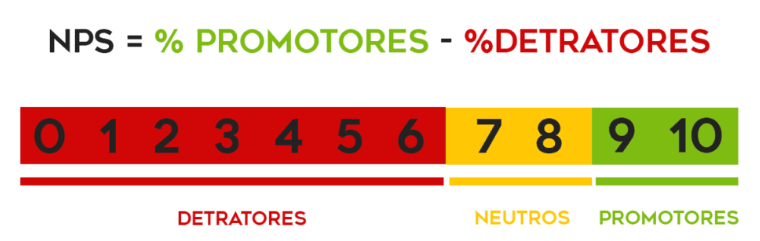




In [10]:
# A funçao categorizar_nps classifica cada cliente da base de acordo
#  com a métrica oficial.

def categorizar_nps(df):
    """Categoriza o NPS com base na coluna nps_score."""
    score = df['nps_score']

    perfil = pd.Series("Detrator", index=df.index)

    return perfil.case_when([
        (score >= 9, "Promotor"),
        (score >= 7, "Neutro")
    ])


df_full_nps['profile_nps'] = categorizar_nps(df_full_nps)
print("5 primeiras linhas com a nova coluna: ")
df_full_nps.head()



5 primeiras linhas com a nova coluna: 


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,profile_nps
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Detrator
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Detrator


In [11]:
print("Distribuição da base de dados")
df_full_nps.profile_nps.value_counts()

Distribuição da base de dados


profile_nps
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

**Passo 3:** Correlação das variaveis da base com o NPS

In [12]:
correlacoes = df_full_nps.corr(numeric_only=True)['nps_score']
correlacoes

customer_id                  0.015162
customer_age                -0.009936
customer_tenure_months      -0.009711
order_id                     0.015162
order_value                  0.036990
items_quantity               0.011468
discount_value               0.025104
payment_installments         0.023718
delivery_time_days           0.000925
delivery_delay_days         -0.597260
freight_value               -0.041087
delivery_attempts            0.027680
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
nps_score                    1.000000
repeat_purchase_30d          0.570324
complaints_count            -0.496800
csat_internal_score          0.563952
Name: nps_score, dtype: float64

In [13]:
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')

In [14]:
# Filtrar correlações mais próximas de +1 ou -1 (excluindo a correlação da própria nps_score com ela mesma)
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')
if not strong_correlations.empty:
    print("Correlações mais fortes com o NPS (próximas de +1 ou -1):\n")
    print(strong_correlations.sort_values(ascending=False))
else:
    print("Não foram encontradas correlações fortes com o NPS (abs >= 0.5).")


Correlações mais fortes com o NPS (próximas de +1 ou -1):

repeat_purchase_30d    0.570324
csat_internal_score    0.563952
delivery_delay_days   -0.597260
Name: nps_score, dtype: float64


In [15]:
result = df_full_nps.groupby('profile_nps').agg(
    total_clientes=('customer_id', 'count'),
    total_recompras_30d=('repeat_purchase_30d', 'sum'),
    taxa_recompra_percent=('repeat_purchase_30d', 'mean'),
    tempo_medio_relacionamento_meses=('customer_tenure_months', 'mean'),
    media_atraso_entrega=('delivery_delay_days', 'mean'),
    media_contatos_suporte=('customer_service_contacts', 'mean'),
    total_reclamacoes=('complaints_count', 'sum')
)

result['taxa_recompra_percent'] = (result['taxa_recompra_percent'] * 100).round(2)
result['tempo_medio_relacionamento_meses'] = result['tempo_medio_relacionamento_meses'].round(1)
result['media_atraso_entrega'] = result['media_atraso_entrega'].round(2)
result['media_contatos_suporte'] = result['media_contatos_suporte'].round(2)

result

,total_clientes,total_recompras_30d,taxa_recompra_percent,tempo_medio_relacionamento_meses,media_atraso_entrega,media_contatos_suporte,total_reclamacoes
profile_nps,,,,,,,
Detrator,2109,0,0.00,61.4,2.41,1.63,9369
Neutro,281,108,38.43,59.8,1.05,1.01,757
Promotor,110,110,100.00,63.0,0.72,0.67,250


**Passo 4** Visualização da distribuiçao do NPS

In [16]:
df_plot = result.reset_index()

/tmp/ipykernel_87802/875874986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)


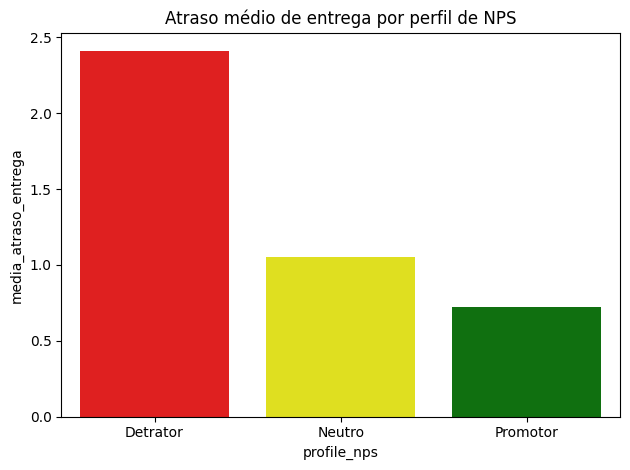

In [17]:
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)
plt.title('Atraso médio de entrega por perfil de NPS')
plt.tight_layout()
plt.show()

/tmp/ipykernel_87802/3367047334.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)


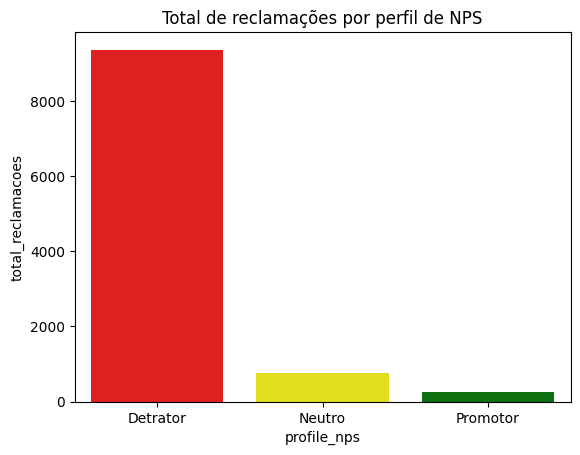

In [23]:
sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)
plt.title('Total de reclamações por perfil de NPS')
plt.show()

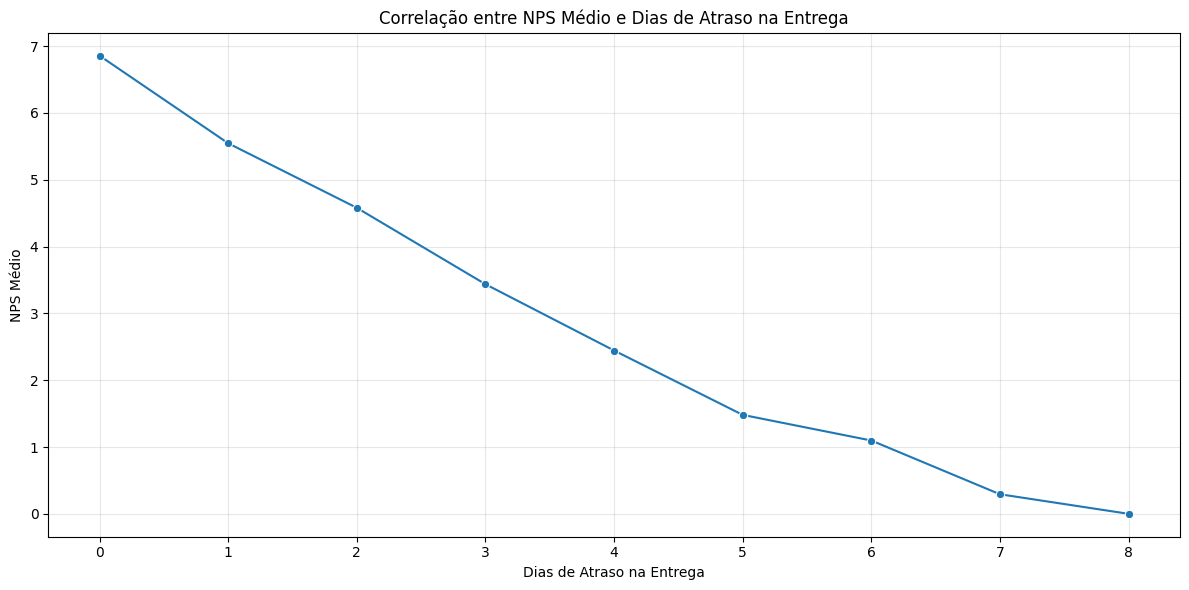

   delivery_delay_days  nps_medio  total_pedidos  taxa_recompra
0                    0   6.856679            277       0.339350
1                    1   5.546179            615       0.147967
2                    2   4.580186            646       0.040248
3                    3   3.436762            525       0.011429
4                    4   2.444444            270       0.003704
5                    5   1.481034            116       0.000000
6                    6   1.097059             34       0.000000
7                    7   0.292857             14       0.000000
8                    8   0.000000              3       0.000000


In [22]:
nps_por_atraso = df_full_nps.groupby('delivery_delay_days').agg(
    nps_medio=('nps_score', 'mean'),
    total_pedidos=('order_id', 'count'),
    taxa_recompra=('repeat_purchase_30d', 'mean')
).reset_index()

# Visualizar a correlação
plt.figure(figsize=(12, 6))
sns.lineplot(data=nps_por_atraso, x=nps_por_atraso['delivery_delay_days'], y=nps_por_atraso['nps_medio'], marker='o')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Médio')
plt.title('Correlação entre NPS Médio e Dias de Atraso na Entrega')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(nps_por_atraso)

/tmp/ipykernel_87802/1733141442.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')


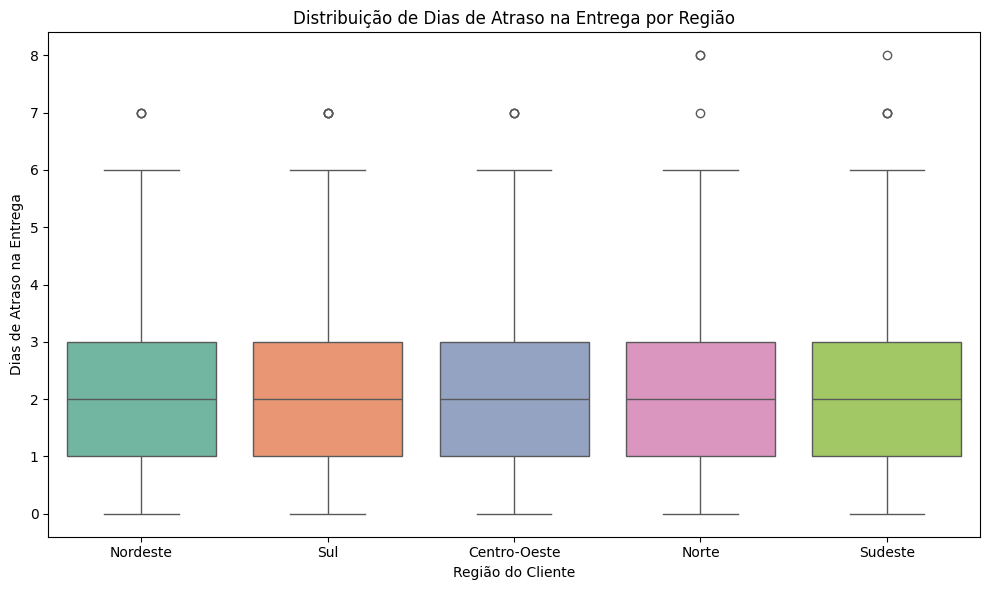

In [25]:
# Visualização comparando dias de atraso na entrega com a região da compra
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')
plt.title('Distribuição de Dias de Atraso na Entrega por Região')
plt.xlabel('Região do Cliente')
plt.ylabel('Dias de Atraso na Entrega')
plt.tight_layout()
plt.show()